# Degree-distribution comparison

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_PATH = ROOT / "data" / "synthetic_perlmutter_memberships_2020_2026.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from artifact_utils import load_memberships, build_user_graph, node_scores, fit_cutoff_power_law, cutoff_pmf, cutoff_band


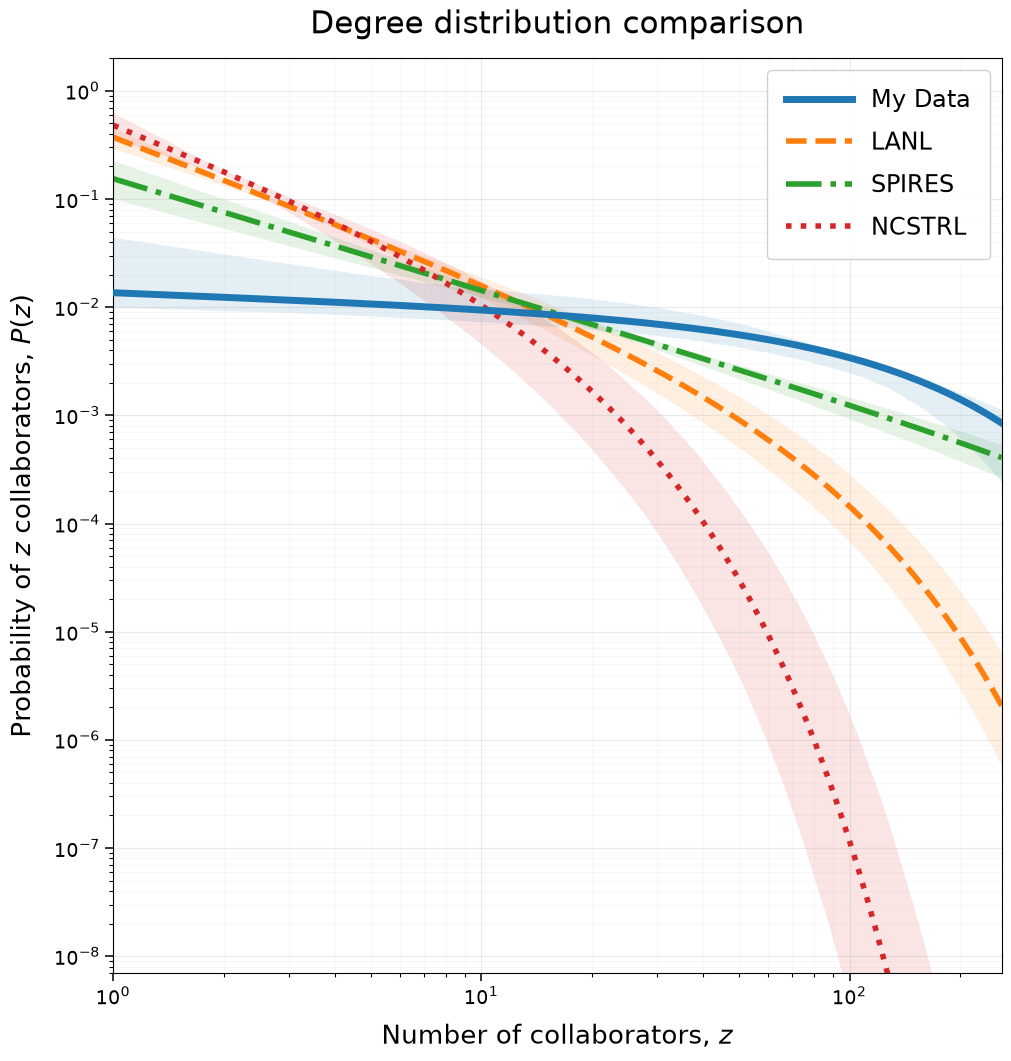

In [3]:
memberships = load_memberships(DATA_PATH)
graph, _ = build_user_graph(memberships)
degrees = node_scores(graph).query("degree > 0")["degree"].to_numpy()
fit = fit_cutoff_power_law(degrees)

newman = {
    "LANL": (1.3, 0.1, 52.9, 4.7, "--"),
    "SPIRES": (1.03, 0.07, 1200.0, 300.0, "-."),
    "NCSTRL": (1.3, 0.2, 10.7, 1.6, ":"),
}
plot_z = np.arange(1, int(degrees.max()) + 1, dtype=float)
norm_z = np.arange(1, max(int(degrees.max()), 30000) + 1, dtype=float)

fig, ax = plt.subplots(figsize=(10, 10.5), constrained_layout=True)
nersc = cutoff_pmf(plot_z, norm_z, fit["tau"], fit["z_c"])
correlation = fit["covariance_log"][0, 1] / np.sqrt(fit["covariance_log"][0, 0] * fit["covariance_log"][1, 1])
low, high = cutoff_band(plot_z, norm_z, fit["tau"], fit["z_c"], fit["tau_se"], fit["z_c_se"], correlation)
line, = ax.plot(plot_z, nersc, linewidth=5.0, label="My Data", zorder=5)
ax.fill_between(plot_z, low, high, color=line.get_color(), alpha=0.12, linewidth=0)

for seed, (name, (tau, tau_se, z_c, z_c_se, style)) in enumerate(newman.items(), 2027):
    curve = cutoff_pmf(plot_z, norm_z, tau, z_c)
    low, high = cutoff_band(plot_z, norm_z, tau, z_c, tau_se, z_c_se, seed=seed)
    line, = ax.plot(plot_z, curve, linestyle=style, linewidth=4.0, label=name)
    ax.fill_between(plot_z, low, high, color=line.get_color(), alpha=0.12, linewidth=0)

ax.set(xscale="log", yscale="log", xlim=(1, degrees.max()), ylim=(7e-9, 2.0))
ax.set_title("Degree distribution comparison", fontsize=22, pad=18)
ax.set_xlabel("Number of collaborators, $z$", fontsize=19, labelpad=10)
ax.set_ylabel("Probability of $z$ collaborators, $P(z)$", fontsize=19, labelpad=12)
ax.tick_params(axis="both", which="major", labelsize=14, length=6, width=1.1)
ax.tick_params(axis="both", which="minor", length=3, width=0.8)
ax.grid(True, which="major", alpha=0.28, linewidth=0.8)
ax.grid(True, which="minor", alpha=0.12, linewidth=0.5)
ax.legend(loc="upper right", fontsize=17, framealpha=0.92, borderpad=0.8, labelspacing=0.8, handlelength=2.8)
fig.savefig(OUTPUT_DIR / "degree_distribution_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
